# Stereocenter Analysis and Enantiomer Validation

This notebook performs a systematic analysis of the stereochemistry encoded in the chirality dataset. It addresses three categories of questions:

**1. Stereocenter inventory**: How many stereocenters does each molecule have? What `ChiralType` tags does RDKit assign? Are there any exotic stereo types (allene, square planar, octahedral) that would break a simple CW/CCW inversion?

**2. Enantiomer generation and validation**: Can we programmatically generate the enantiomer of each molecule and confirm it matches the paired `SMILES_opp`? This validates both the dataset pairing and our inversion function.

**3. Additional structural integrity checks**: Are there meso compounds? Does double-inversion return the original? Is there full agreement between the CSV label columns and RDKit's computed CIP labels?

## Background: `get_enantiomer_smiles()`

The enantiomer of a molecule is its non-superimposable mirror image. For molecules with only tetrahedral stereocenters, generating the enantiomer requires flipping every tagged stereocenter simultaneously — flipping only a subset produces a diastereomer, not an enantiomer.

RDKit encodes tetrahedral chirality via `atom.GetChiralTag()`. The full set of `ChiralType` values (from the RDKit C++ source `Atom.h` and Python docs at `rdkit.Chem.rdchem`):

| Value | Integer | Meaning |
|---|---|---|
| `CHI_UNSPECIFIED` | 0 | No stereo annotation at this atom |
| `CHI_TETRAHEDRAL_CW` | 1 | Clockwise parity — SMILES `@@` |
| `CHI_TETRAHEDRAL_CCW` | 2 | Counter-clockwise parity — SMILES `@` |
| `CHI_OTHER` | 3 | Unrecognized chirality |
| `CHI_TETRAHEDRAL` | 4 | Tetrahedral with permutation flag (newer API) |
| `CHI_ALLENE` | 5 | Allene-type axial chirality |
| `CHI_SQUAREPLANAR` | 6 | Square planar geometry |
| `CHI_TRIGONALBIPYRAMIDAL` | 7 | Trigonal bipyramidal geometry |
| `CHI_OCTAHEDRAL` | 8 | Octahedral geometry |

The `get_enantiomer_smiles()` function in this notebook flips CW↔CCW and raises `ValueError` for any other tagged type.

**Critical note on canonical SMILES:** All comparisons must be performed on *canonical* SMILES (`Chem.MolToSmiles(Chem.MolFromSmiles(smi))`), not raw string comparison. Direct string comparison of enantiomers is a common source of incorrect logic because the same molecule can be written as many different SMILES strings.

In [1]:
import time

import pandas as pd
import numpy as np
from collections import Counter

from rdkit import Chem
from rdkit.Chem import rdCIPLabeler
from rdkit.Chem.rdchem import ChiralType

## Load data

In [2]:
input_path = "class_all.csv"
df = pd.read_csv(input_path, index_col=0)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset shape: (3858, 6)
Columns: ['SMILES', 'SMILES_opp', 'TR/TE', 'F/L_class', '@/@@_class', 'R/S_class']


,SMILES,SMILES_opp,TR/TE,F/L_class,@/@@_class,R/S_class
0,Brc1ccc2c(c1)N[C@H](c1ccccc1)CC2,Brc1ccc2c(c1)N[C@@H](c1ccccc1)CC2,TE,F,@,S
1,Brc1ccc2c(c1)N[C@@H](c1ccccc1)CC2,Brc1ccc2c(c1)N[C@H](c1ccccc1)CC2,TE,L,@@,R
2,C#CCO[C@H](CSc1nc2cc(Cl)ccc2s1)CN(C)C(c1ccccc1...,C#CCO[C@@H](CSc1nc2cc(Cl)ccc2s1)CN(C)C(c1ccccc...,TE,F,@,S
3,C#CCO[C@@H](CSc1nc2cc(Cl)ccc2s1)CN(C)C(c1ccccc...,C#CCO[C@H](CSc1nc2cc(Cl)ccc2s1)CN(C)C(c1ccccc1...,TE,L,@@,R
4,C=C(C(C)=O)[C@@H](CC(=O)c1ccc(Br)cc1)C(=O)OCC,C=C(C(C)=O)[C@H](CC(=O)c1ccc(Br)cc1)C(=O)OCC,TE,F,@@,R


## Helper functions

### `get_enantiomer_smiles()`
Flips all tetrahedral CW↔CCW stereocenters. Returns the canonical SMILES of the enantiomer, or `None` if the SMILES cannot be parsed. Raises `ValueError` for any `ChiralType` other than CW, CCW, or UNSPECIFIED — ensuring exotic stereo types fail loudly.

### `canonicalize()`
Returns canonical SMILES. All comparisons in this notebook use canonical SMILES to avoid false mismatches from equivalent but differently-written strings.

In [3]:
def get_enantiomer_smiles(smi: str) -> str | None:
    """
    Generate the enantiomer by flipping all tetrahedral stereocenters.

    Flips CHI_TETRAHEDRAL_CW <-> CHI_TETRAHEDRAL_CCW for every atom.
    CHI_UNSPECIFIED atoms are left unchanged.
    Any other ChiralType raises ValueError to prevent silent errors.

    Args:
        smi: SMILES string of the input molecule.

    Returns:
        Canonical SMILES of the enantiomer, or None if parsing fails.

    Raises:
        ValueError: If any atom has a ChiralType other than CW, CCW,
            or UNSPECIFIED (e.g. allenes, square planar centers).
    """
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    # RWMol extends ROMol with editing capabilities, allowing addition and removal of atoms and bonds
    # however, SetChiralTag() works on the plain Mol object tooso calling it directly on the MolFromSmiles result works without wrapping in RWMol
    rwmol = Chem.RWMol(mol)
    for atom in rwmol.GetAtoms():
        chi = atom.GetChiralTag()
        if chi == ChiralType.CHI_TETRAHEDRAL_CW:
            atom.SetChiralTag(ChiralType.CHI_TETRAHEDRAL_CCW)
        elif chi == ChiralType.CHI_TETRAHEDRAL_CCW:
            atom.SetChiralTag(ChiralType.CHI_TETRAHEDRAL_CW)
        elif chi == ChiralType.CHI_UNSPECIFIED:
            pass
        else:
            raise ValueError(
                f"Atom {atom.GetIdx()} ({atom.GetSymbol()}) has unhandled "
                f"ChiralType: {chi}. SMILES: {smi} Cannot guarantee enantiomer is correct"
            )
    return Chem.MolToSmiles(rwmol)


def canonicalize(smi: str) -> str | None:
    """
    Return canonical SMILES, or None if the SMILES cannot be parsed.

    Args:
        smi: Any valid SMILES string.

    Returns:
        Canonical SMILES string, or None if parsing fails.
    """
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol, canonical=True) if mol is not None else None

## Section 1: SMILES parsing validation

Before any analysis, confirm every SMILES string in both columns parses successfully. A parse failure would silently propagate `None` through all downstream comparisons.

In [4]:
parse_fail_smiles = df["SMILES"].apply(lambda s: Chem.MolFromSmiles(s) is None)
parse_fail_opp    = df["SMILES_opp"].apply(lambda s: Chem.MolFromSmiles(s) is None)

print(f"SMILES parse failures:     {parse_fail_smiles.sum()}")
print(f"SMILES_opp parse failures: {parse_fail_opp.sum()}")

if not parse_fail_smiles.any() and not parse_fail_opp.any():
    print("All SMILES strings parse successfully.")

SMILES parse failures:     0
SMILES_opp parse failures: 0
All SMILES strings parse successfully.


## Section 2: ChiralType inventory

For `get_enantiomer_smiles()` to be safe across the entire dataset, every tagged atom must use only `CHI_TETRAHEDRAL_CW` or `CHI_TETRAHEDRAL_CCW`. This cell verifies that no exotic types (allene, square planar, octahedral) are present, which would cause the function to raise `ValueError`.

In [5]:
CHIRAL_TYPE_NAMES = {
    ChiralType.CHI_UNSPECIFIED:         "CHI_UNSPECIFIED",
    ChiralType.CHI_TETRAHEDRAL_CW:      "CHI_TETRAHEDRAL_CW  (SMILES @@)",
    ChiralType.CHI_TETRAHEDRAL_CCW:     "CHI_TETRAHEDRAL_CCW (SMILES @)",
    ChiralType.CHI_OTHER:               "CHI_OTHER",
    ChiralType.CHI_TETRAHEDRAL:         "CHI_TETRAHEDRAL (permutation flag)",
    ChiralType.CHI_ALLENE:              "CHI_ALLENE",
    ChiralType.CHI_SQUAREPLANAR:        "CHI_SQUAREPLANAR",
    ChiralType.CHI_TRIGONALBIPYRAMIDAL: "CHI_TRIGONALBIPYRAMIDAL",
    ChiralType.CHI_OCTAHEDRAL:          "CHI_OCTAHEDRAL",
}

def get_tag_counts(col):
    counts = Counter()
    for smi in col:
        mol = Chem.MolFromSmiles(smi)
        for atom in mol.GetAtoms():
            counts[atom.GetChiralTag()] += 1
    return counts

tag_counts_smiles = get_tag_counts(df["SMILES"])
tag_counts_opp    = get_tag_counts(df["SMILES_opp"])

print("ChiralType distribution — SMILES column:")
for tag, count in sorted(tag_counts_smiles.items(), key=lambda x: -x[1]):
    print(f"  {CHIRAL_TYPE_NAMES.get(tag, str(tag))}: {count:,}")

print("\nChiralType distribution — SMILES_opp column:")
for tag, count in sorted(tag_counts_opp.items(), key=lambda x: -x[1]):
    print(f"  {CHIRAL_TYPE_NAMES.get(tag, str(tag))}: {count:,}")

safe = {ChiralType.CHI_TETRAHEDRAL_CW, ChiralType.CHI_TETRAHEDRAL_CCW, ChiralType.CHI_UNSPECIFIED}
unsafe = (set(tag_counts_smiles) | set(tag_counts_opp)) - safe
if not unsafe:
    print("\nOnly CW, CCW, and UNSPECIFIED tags present.")
    print("  get_enantiomer_smiles() is safe to apply to every row.")
else:
    print(f"\nUnsafe ChiralTypes found: {unsafe}")

ChiralType distribution — SMILES column:
  CHI_UNSPECIFIED: 90,078
  CHI_TETRAHEDRAL_CCW (SMILES @): 1,929
  CHI_TETRAHEDRAL_CW  (SMILES @@): 1,929

ChiralType distribution — SMILES_opp column:
  CHI_UNSPECIFIED: 90,078
  CHI_TETRAHEDRAL_CW  (SMILES @@): 1,929
  CHI_TETRAHEDRAL_CCW (SMILES @): 1,929

Only CW, CCW, and UNSPECIFIED tags present.
  get_enantiomer_smiles() is safe to apply to every row.


## Section 3: Stereocenter count per molecule

Count stereocenters two ways:

**Tagged** (`GetChiralTag() != UNSPECIFIED`) — atoms explicitly annotated with `@` or `@@` in the SMILES string. This is the count that drives fingerprint encoding and enantiomer inversion.

**Perceived** (`FindMolChiralCenters(includeUnassigned=True)`) — all atoms that are or could be stereocenters including unspecified ones (marked `'?'`). Unspecified centers are structurally chiral but have no `@`/`@@` annotation. They do not affect our enantiomer function but reveal structural complexity.

Note: `FindMolChiralCenters` can return more centers than are tagged because it uses RDKit's stereo perception to find *potential* centers regardless of whether they are annotated in the SMILES.

In [6]:
def analyze_stereocenters(smi: str) -> dict:
    """Count stereocenters by two methods.

    Args:
        smi: SMILES string.

    Returns:
        Dict with tagged count, perceived count, and unspecified center count.
    """
    mol = Chem.MolFromSmiles(smi)
    tagged = sum(1 for a in mol.GetAtoms() if a.GetChiralTag() != ChiralType.CHI_UNSPECIFIED)
    perceived = Chem.FindMolChiralCenters(mol, includeUnassigned=True, useLegacyImplementation=False)
    return {
        "tagged":               tagged,
        "perceived":            len(perceived),
        "unspecified_centers":  sum(1 for _, cip in perceived if cip == "?"),
    }

In [7]:
START = time.time()
stereo_df = df["SMILES"].apply(analyze_stereocenters)
print(f"Elapsed time: {time.time() - START:.2f} seconds")

Elapsed time: 5.87 seconds


In [8]:
type(stereo_df)

pandas.Series

In [9]:
# the analyze_stereocenters() function returns a dictionary for reach row
# this is pd.Series with each row being a dictionary
stereo_df

0       {'tagged': 1, 'perceived': 1, 'unspecified_cen...
1       {'tagged': 1, 'perceived': 1, 'unspecified_cen...
2       {'tagged': 1, 'perceived': 1, 'unspecified_cen...
3       {'tagged': 1, 'perceived': 1, 'unspecified_cen...
4       {'tagged': 1, 'perceived': 1, 'unspecified_cen...
                              ...                        
3853    {'tagged': 1, 'perceived': 1, 'unspecified_cen...
3854    {'tagged': 1, 'perceived': 1, 'unspecified_cen...
3855    {'tagged': 1, 'perceived': 1, 'unspecified_cen...
3856    {'tagged': 1, 'perceived': 1, 'unspecified_cen...
3857    {'tagged': 1, 'perceived': 1, 'unspecified_cen...
Name: SMILES, Length: 3858, dtype: object

In [10]:
# must apply pd.Series to take each dict and expand it to a proper row where keys become column names
stereo_df = stereo_df.apply(pd.Series)
stereo_df

,tagged,perceived,unspecified_centers
0,1,1,0
1,1,1,0
2,1,1,0
3,1,1,0
4,1,1,0
...,...,...,...
3853,1,1,0
3854,1,1,0
3855,1,1,0
3856,1,1,0


In [11]:
# every molecule has exactly 1 @/@@ annotation. this is the tagged count
print("Distribution of TAGGED stereocenters (@ or @@ in SMILES):")
print(stereo_df["tagged"].value_counts().sort_index().to_string())

Distribution of TAGGED stereocenters (@ or @@ in SMILES):
tagged
1    3858


The perceived count uses `FindMolChiralCenters(includeUnassigned=True)` and asks RDKit's stereo perception to find every atom that *could* be a stereocenter based on graph topology — including atoms that are structurally tetrahedral with four distinct substituents but have no @/@@ annotation. These appear as `'?'` in the output.

In [12]:
# 3,856 molecules have 1 stereocenter that is fully specified
# 2 molecules have 1 stereocenter that is specified and 4 that are unspecified
print("Distribution of PERCEIVED stereocenters (includes unspecified ?):")
print(stereo_df["perceived"].value_counts().sort_index().to_string())

Distribution of PERCEIVED stereocenters (includes unspecified ?):
perceived
1    3856
5       2


The two outlier molecules (rows 798–799) contain an adamantane cage, which has four bridgehead carbons so it appears to RDKit's perception as potential stereocenters. However, the cage has internal symmetry: the four bridgehead carbons are equivalent by the molecular symmetry, so none of them is a true stereocenter. RDKit conservatively marks them as `'?'` (potentially chiral but unspecified) rather than asserting they are or are not stereocenters.

In [13]:
has_unspec = stereo_df["unspecified_centers"] > 0
print(f"Molecules with unspecified potential stereocenters: {has_unspec.sum()}")
if has_unspec.any():
    rows = df[has_unspec].copy()
    rows["unspecified_count"] = stereo_df[has_unspec]["unspecified_centers"]
    print(rows[["SMILES", "@/@@_class", "R/S_class", "unspecified_count"]].to_string())

Molecules with unspecified potential stereocenters: 2
                                                                                    SMILES @/@@_class R/S_class  unspecified_count
798  c1ccc(-c2c(-c3ccccc3)n([C@@H](c3ccccc3)c3ccc(NCC45CC6CC(CC(C6)C4)C5)cc3)c3ccccc23)cc1         @@         S                  4
799   c1ccc(-c2c(-c3ccccc3)n([C@H](c3ccccc3)c3ccc(NCC45CC6CC(CC(C6)C4)C5)cc3)c3ccccc23)cc1          @         R                  4


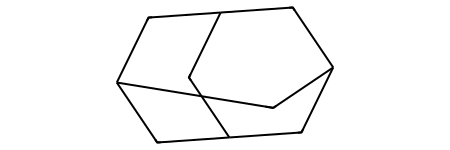

In [14]:
smi = 'C1C3CC2CC(CC1C2)C3'
Chem.MolFromSmiles(smi)

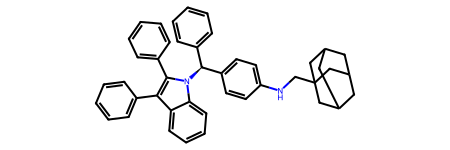

In [15]:
smi = df.iloc[798].SMILES
Chem.MolFromSmiles(smi)

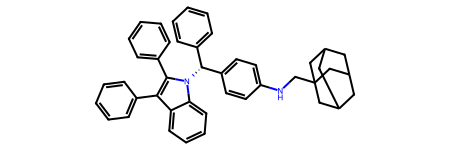

In [16]:
smi = df.iloc[799].SMILES
Chem.MolFromSmiles(smi)

## Section 4: Forward validation i.e., SMILES → enantiomer → compare to SMILES_opp

For every row:
1. Compute `get_enantiomer_smiles(SMILES)` by flipping all CW↔CCW tags
2. Canonicalize the resulting enatiomer smiles with `Chem.MolToSmiles()`
3. Compare to `canonicalize(SMILES_opp)`

A 100% match rate confirms both that the dataset pairing is correct and that our inversion function produces exactly the paired enantiomer.

In [17]:
forward_results = []
for idx, row in df.iterrows():
    try:
        enan = get_enantiomer_smiles(row["SMILES"])
        can_opp = canonicalize(row["SMILES_opp"])
        forward_results.append({"idx": idx, "match": enan == can_opp, "error": None})
    except ValueError as e:
        forward_results.append({"idx": idx, "match": False, "error": str(e)})

fwd_df = pd.DataFrame(forward_results)
n_match = fwd_df["match"].sum()
n_error = fwd_df["error"].notna().sum()
n_fail  = len(fwd_df) - n_match - n_error

print("Forward validation (SMILES → enantiomer == SMILES_opp):")
print(f"  Match:    {n_match:>6,} / {len(fwd_df):,}")
print(f"  Mismatch: {n_fail:>6,}")
print(f"  Error:    {n_error:>6,}")

if n_fail > 0:
    print("\nMismatch rows:")
    print(fwd_df[~fwd_df["match"] & fwd_df["error"].isna()].to_string())
if n_error > 0:
    print("\nError rows:")
    print(fwd_df[fwd_df["error"].notna()].to_string())

Forward validation (SMILES → enantiomer == SMILES_opp):
  Match:     3,858 / 3,858
  Mismatch:      0
  Error:         0


## Section 5: Reverse validation i.e., SMILES_opp → enantiomer → compare to SMILES

The reverse direction tests the other column. Both forward and reverse must produce 100% matches. A discrepancy would indicate asymmetric encoding — one column using a different SMILES convention than the other.

In [18]:
reverse_results = []
for idx, row in df.iterrows():
    try:
        enan = get_enantiomer_smiles(row["SMILES_opp"])
        can_orig = canonicalize(row["SMILES"])
        reverse_results.append({"idx": idx, "match": enan == can_orig, "error": None})
    except ValueError as e:
        reverse_results.append({"idx": idx, "match": False, "error": str(e)})

rev_df = pd.DataFrame(reverse_results)
n_match_r = rev_df["match"].sum()
n_error_r = rev_df["error"].notna().sum()
n_fail_r  = len(rev_df) - n_match_r - n_error_r

print("Reverse validation (SMILES_opp → enantiomer == SMILES):")
print(f"  Match:    {n_match_r:>6,} / {len(rev_df):,}")
print(f"  Mismatch: {n_fail_r:>6,}")
print(f"  Error:    {n_error_r:>6,}")

if n_fail_r > 0:
    print("\nMismatch rows:")
    print(rev_df[~rev_df["match"] & rev_df["error"].isna()].to_string())

Reverse validation (SMILES_opp → enantiomer == SMILES):
  Match:     3,858 / 3,858
  Mismatch:      0
  Error:         0


## Section 6: Idempotency i.e., enantiomer(enantiomer(A)) == A

The enantiomer operation is its own inverse. Applying it twice must return the original molecule. This is a mathematical property of mirror-image inversion. A failure here would indicate a bug in canonicalization or in the `SetChiralTag` calls leaving the molecule in an inconsistent state.

In [19]:
idem_results = []
for smi in df["SMILES"]:
    can_orig    = canonicalize(smi)
    enan        = get_enantiomer_smiles(smi)
    double_enan = get_enantiomer_smiles(enan) if enan is not None else None
    idem_results.append(double_enan == can_orig)

n_idem_pass = sum(idem_results)
print(f"Idempotency: enantiomer(enantiomer(A)) == canonical(A)")
print(f"  Pass: {n_idem_pass:,} / {len(idem_results):,}")
if n_idem_pass < len(idem_results):
    fails = [df.iloc[i]["SMILES"] for i, ok in enumerate(idem_results) if not ok]
    print(f"  Fail: {len(fails)} molecules")
    for s in fails[:5]:
        print(f"    {s}")

Idempotency: enantiomer(enantiomer(A)) == canonical(A)
  Pass: 3,858 / 3,858


## Section 7: Meso compound check

A meso compound has stereocenters but is achiral overall due to an internal plane of symmetry. Its enantiomer is identical to itself: `enantiomer(A) == canonical(A)`.

This is an important edge case for the `morgan_delta_opp` featurization: a meso compound would produce a zero delta vector even though it has a tagged stereocenter — `FP(mol) - FP(enantiomer)` would be the zero vector, making it indistinguishable from an achiral molecule.

Meso compounds should not exist in this dataset by construction — they cannot have distinct chromatographic enantiomers — but it is worth verifying explicitly.

In [20]:
meso_indices = []
for idx, row in df.iterrows():
    can_orig = canonicalize(row["SMILES"])
    enan     = get_enantiomer_smiles(row["SMILES"])
    if enan == can_orig:
        meso_indices.append(idx)

print(f"Meso compounds detected: {len(meso_indices)}")
if meso_indices:
    print("These molecules are their own enantiomers:")
    print(df.loc[meso_indices][["SMILES","@/@@_class","R/S_class","F/L_class"]].to_string())
else:
    print("✓ No meso compounds.")
    print("  All molecules are distinguishable from their enantiomers.")
    print("  This is expected: every molecule in the dataset has a measured")
    print("  chiral HPLC retention time, requiring two distinct enantiomers.")

Meso compounds detected: 0
✓ No meso compounds.
  All molecules are distinguishable from their enantiomers.
  This is expected: every molecule in the dataset has a measured
  chiral HPLC retention time, requiring two distinct enantiomers.


## Section 8: Verify CSV label columns against RDKit-computed values

The dataset has three chirality columns: `@/@@_class`, `R/S_class`, and `F/L_class`. Here we recompute the CIP label and the `@/@@` tag independently from the SMILES using RDKit and compare them to the CSV values. This:

1. Confirms the CSV labels are internally consistent with the SMILES
2. Provides a concrete, row-by-row demonstration of why `@/@@` and `R/S` are near-independent (Cramér's V ≈ 0.02 from the association analysis notebook)

The `@` SMILES tag encodes parity *relative to the atom ordering in the canonical SMILES*, while the CIP R/S label is determined by atomic priority rules. Because canonical atom ordering is not determined by CIP priorities, the same physical stereocenter can be `@` in SMILES and either R or S in CIP notation depending on what other atoms are attached.

In [21]:
def get_rdkit_stereo(smi: str) -> dict:
    """Compute RDKit CIP label and @/@@ tag for a SMILES string.

    Args:
        smi: SMILES string with at least one tagged stereocenter.

    Returns:
        Dict with rdkit_cip (R, S, or label string) and rdkit_at (@ or @@).
    """
    mol = Chem.MolFromSmiles(smi)
    rdCIPLabeler.AssignCIPLabels(mol)
    cip_labels, at_symbols = [], []
    for atom in mol.GetAtoms():
        chi = atom.GetChiralTag()
        if chi == ChiralType.CHI_TETRAHEDRAL_CW:
            at_symbols.append("@@")
        elif chi == ChiralType.CHI_TETRAHEDRAL_CCW:
            at_symbols.append("@")
        if atom.HasProp("_CIPCode"):
            cip_labels.append(atom.GetProp("_CIPCode"))
    return {
        "rdkit_cip": cip_labels[0] if len(cip_labels) == 1 else str(cip_labels),
        "rdkit_at":  at_symbols[0] if len(at_symbols) == 1 else str(at_symbols),
    }

computed = df["SMILES"].apply(get_rdkit_stereo).apply(pd.Series)
df_check = df.copy()
df_check["rdkit_cip"] = computed["rdkit_cip"]
df_check["rdkit_at"]  = computed["rdkit_at"]

cip_agree = df_check["R/S_class"] == df_check["rdkit_cip"]
at_agree  = df_check["@/@@_class"] == df_check["rdkit_at"]

print("Agreement between CSV labels and RDKit-computed values:")
print(f"  R/S_class matches rdkit CIP:  {cip_agree.sum():,} / {len(df):,}  ({cip_agree.mean()*100:.2f}%)")
print(f"  @/@@_class matches rdkit tag: {at_agree.sum():,}  / {len(df):,}  ({at_agree.mean()*100:.2f}%)")
print()
print("Cross-tabulation: @/@@ (CSV) vs RDKit-computed CIP label:")
print(pd.crosstab(df_check["@/@@_class"], df_check["rdkit_cip"]))
print()
print("Interpretation: near-equal cell counts confirm @/@@ and R/S are near-independent.")
print("The @/@@  tag reflects SMILES atom ordering; R/S reflects atomic priorities.")

Agreement between CSV labels and RDKit-computed values:
  R/S_class matches rdkit CIP:  3,858 / 3,858  (100.00%)
  @/@@_class matches rdkit tag: 3,150  / 3,858  (81.65%)

Cross-tabulation: @/@@ (CSV) vs RDKit-computed CIP label:
rdkit_cip     R    S
@/@@_class          
@           983  946
@@          946  983

Interpretation: near-equal cell counts confirm @/@@ and R/S are near-independent.
The @/@@  tag reflects SMILES atom ordering; R/S reflects atomic priorities.


Every R/S label in the CSV matches what RDKit independently computes from the SMILES using `rdCIPLabeler`. This confirms the dataset was constructed correctly i.e., the CIP labels are consistent with the molecular graphs. There is no labeling error in the R/S column. The 100% agreement is expected and reassuring.

The 708 molecules (18.35%) that disagreed on the @/@_class label simply means that the canonical SMILES that RDKit generates internally may differ from the SMILES strings stored in the CSV. This does not mean the CSV is wrong. When the atom ordering changes (due to slightly different SMILES), the @/@@ parity tag must flip to encode the same 3D arrangement.
**The same physical stereocenter can be written as @ or @@ depending on how the SMILES is written, and both are correct as long as they agree with the 3D arrangement implied by the atom ordering.**
- Also the function above hardcodes `ChiralType.CHI_TETRAHEDRAL_CW` to `@@` and `ChiralType.CHI_TETRAHEDRAL_CCW` to `@` which is not correct for atoms with implicit hydrogens.

**The main result from Section 8 is identifying the near-independence between @/@@ and R/S.**

In [22]:
at_to_R = df_check[(df_check["@/@@_class"] == "@") & (df_check["rdkit_cip"] == "R")]
at_to_S = df_check[(df_check["@/@@_class"] == "@") & (df_check["rdkit_cip"] == "S")]
print(f"Molecules where @ (CCW) -> CIP R: {len(at_to_R):,}")
print(f"Molecules where @ (CCW) -> CIP S: {len(at_to_S):,}")
print()
print("First 5 examples of @ -> R (showing that @ does NOT always mean S):")
print(at_to_R[["SMILES","@/@@_class","R/S_class","rdkit_cip"]].head(5).to_string())

Molecules where @ (CCW) -> CIP R: 983
Molecules where @ (CCW) -> CIP S: 946

First 5 examples of @ -> R (showing that @ does NOT always mean S):
                                                                      SMILES @/@@_class R/S_class rdkit_cip
12                  C=C1c2cc(C)c(C)cc2N(S(=O)(=O)C(F)(F)F)[C@]1(CCC)c1ccccc1          @         R         R
15  C=C1c2ccc(C)cc2N(S(=O)(=O)C(F)(F)F)[C@H]1N(c1ccccc1)S(=O)(=O)c1ccc(C)cc1          @         R         R
16                                           C=C[C@H](C1CCCCC1)n1ccc2ccccc21          @         R         R
38                 CC(=O)c1ccc([C@H](C)CC(=O)NC(C)(C)c2ccc(-c3ccccc3)cn2)cc1          @         R         R
40             CC(=O)c1ccc([C@H](CCc2cccc3ccccc23)CC(=O)NC(C)(C)c2ccccn2)cc1          @         R         R


## Section 9: Validation summary

In [23]:
print("=" * 65)
print("VALIDATION SUMMARY")
print("=" * 65)
print(f"  SMILES parse failures:                    {parse_fail_smiles.sum():>6,}")
print(f"  SMILES_opp parse failures:                {parse_fail_opp.sum():>6,}")
print()
print(f"  Molecules with only CW/CCW/UNSPECIFIED:   {(~has_unspec).sum():>6,} / {len(df):,}")
print(f"  Molecules with unspecified ? centers:     {has_unspec.sum():>6,}")
print()
print(f"  Forward match (SMILES->enan==SMILES_opp): {n_match:>6,} / {len(df):,}")
print(f"  Reverse match (SMILES_opp->enan==SMILES): {n_match_r:>6,} / {len(df):,}")
print()
print(f"  Idempotency passes:                       {n_idem_pass:>6,} / {len(df):,}")
print(f"  Meso compounds:                           {len(meso_indices):>6,}")
print()
print(f"  R/S agreement (CSV vs RDKit CIP):         {cip_agree.sum():>6,} / {len(df):,}  ({cip_agree.mean()*100:.1f}%)")
print(f"  @/@@ agreement (CSV vs RDKit tag):        {at_agree.sum():>6,} / {len(df):,}  ({at_agree.mean()*100:.1f}%)")
print("=" * 65)

VALIDATION SUMMARY
  SMILES parse failures:                         0
  SMILES_opp parse failures:                     0

  Molecules with only CW/CCW/UNSPECIFIED:    3,856 / 3,858
  Molecules with unspecified ? centers:          2

  Forward match (SMILES->enan==SMILES_opp):  3,858 / 3,858
  Reverse match (SMILES_opp->enan==SMILES):  3,858 / 3,858

  Idempotency passes:                        3,858 / 3,858
  Meso compounds:                                0

  R/S agreement (CSV vs RDKit CIP):          3,858 / 3,858  (100.0%)
  @/@@ agreement (CSV vs RDKit tag):         3,150 / 3,858  (81.6%)


As explained above, the only 2 molecules with unspecified `?` centers are rows 798 and 799 with adamantane cage.